# **Zee Recommender Systems Case Study:**

# **🎯 Problem Statement:**
Create a Recommender System to show personalized movie recommendations based on ratings given by a user and other users similar to them in order to improve user experience.

# **🧩 Part A: Data Ingestion & Formatting**

In [ ]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.graph_objects as go
warnings.filterwarnings('ignore')

In [ ]:
# Read the datasets and create a dataframe for analysis. Print the first 5 rows
ratings_df = pd.read_csv("/content/drive/MyDrive/Datasets/ZEE-data/zee-ratings.dat", sep = "::", engine = "python")
ratings_df.head()

,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [ ]:
# Read the datasets and create a dataframe for analysis. Print the first 5 rows
movies_df = pd.read_csv("/content/drive/MyDrive/Datasets/ZEE-data/zee-movies.dat", sep = "::", engine = "python", encoding = "ISO-8859-1")
movies_df.head()

,Movie ID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# Rename Movie ID column to MovieID
movies_df.rename(columns = {"Movie ID": "MovieID"}, inplace = True)
movies_df.head()

,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
# Read the datasets and create a dataframe for analysis. Print the first 5 rows
users_df = pd.read_csv("/content/drive/MyDrive/Datasets/ZEE-data/zee-users.dat", sep = "::", engine = "python")
users_df.head()

,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [ ]:
# Basic Structure Checks
print("Ratings shape:", ratings_df.shape)
print("Movies shape:", movies_df.shape)
print("Users shape:", users_df.shape)

Ratings shape: (1000209, 4)
Movies shape: (3883, 3)
Users shape: (6040, 5)


In [ ]:
# Data Types
print("\nRatings data types:\n", ratings_df.dtypes)
print("\nMovies data types:\n", movies_df.dtypes)
print("\nUsers data types:\n", users_df.dtypes)


Ratings data types:
 UserID       int64
MovieID      int64
Rating       int64
Timestamp    int64
dtype: object

Movies data types:
 MovieID     int64
Title      object
Genres     object
dtype: object

Users data types:
 UserID         int64
Gender        object
Age            int64
Occupation     int64
Zip-code      object
dtype: object


In [ ]:
# Info
print("\nRatings info:\n", ratings_df.info())
print("\nMovies info:\n", movies_df.info())
print("\nUsers info:\n", users_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   UserID     1000209 non-null  int64
 1   MovieID    1000209 non-null  int64
 2   Rating     1000209 non-null  int64
 3   Timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB

Ratings info:
 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   MovieID  3883 non-null   int64 
 1   Title    3883 non-null   object
 2   Genres   3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB

Movies info:
 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UserID      6040 non-null   int64 


In [ ]:
# Statistical Summary
print("\nRatings summary:\n", ratings_df.describe())
print("\nUsers summary:\n", users_df.describe())


Ratings summary:
              UserID       MovieID        Rating     Timestamp
count  1.000209e+06  1.000209e+06  1.000209e+06  1.000209e+06
mean   3.024512e+03  1.865540e+03  3.581564e+00  9.722437e+08
std    1.728413e+03  1.096041e+03  1.117102e+00  1.215256e+07
min    1.000000e+00  1.000000e+00  1.000000e+00  9.567039e+08
25%    1.506000e+03  1.030000e+03  3.000000e+00  9.653026e+08
50%    3.070000e+03  1.835000e+03  4.000000e+00  9.730180e+08
75%    4.476000e+03  2.770000e+03  4.000000e+00  9.752209e+08
max    6.040000e+03  3.952000e+03  5.000000e+00  1.046455e+09

Users summary:
             UserID          Age   Occupation
count  6040.000000  6040.000000  6040.000000
mean   3020.500000    30.639238     8.146854
std    1743.742145    12.895962     6.329511
min       1.000000     1.000000     0.000000
25%    1510.750000    25.000000     3.000000
50%    3020.500000    25.000000     7.000000
75%    4530.250000    35.000000    14.000000
max    6040.000000    56.000000    20.000000


In [ ]:
# Check for duplicate values
print("\nDuplicate values in ratings:", ratings_df.duplicated().sum())
print("\nDuplicate values in movies:", movies_df.duplicated().sum())
print("\nDuplicate values in users:", users_df.duplicated().sum())


Duplicate values in ratings: 0

Duplicate values in movies: 0

Duplicate values in users: 0


In [ ]:
# Check for missing values and their percentage
# Create a dictionary of dataframes
dfs = {'Ratings': ratings_df, 'Movies': movies_df, 'Users': users_df}

# Empty list to store results
missing_summary = []

# Loop through each dataframe
for name, df in dfs.items():
    total_rows = len(df)

    missing_values = df.isnull().sum()
    missing_percentage = (missing_values / total_rows) * 100

    # Create a temp dataframe
    temp_df = pd.DataFrame({'Dataset': name, 'Column': missing_values.index, 'Missing Values': missing_values.values,
                            'Percentage (%)': missing_percentage.values})
    missing_summary.append(temp_df)

# Combine all into one dataframe
final_missing_df = pd.concat(missing_summary, ignore_index = True)

# Display
final_missing_df.pivot(index = 'Column', columns = 'Dataset', values = 'Missing Values').fillna(0)

Dataset,Movies,Ratings,Users
Column,,,
Age,0.0,0.0,0.0
Gender,0.0,0.0,0.0
Genres,0.0,0.0,0.0
MovieID,0.0,0.0,0.0
Occupation,0.0,0.0,0.0
Rating,0.0,0.0,0.0
Timestamp,0.0,0.0,0.0
Title,0.0,0.0,0.0
UserID,0.0,0.0,0.0


In [ ]:
# Number of unique values
print("\nUnique values in ratings:\n", ratings_df.nunique())
print("\nUnique values in movies:\n", movies_df.nunique())
print("\nUnique values in users:\n", users_df.nunique())


Unique values in ratings:
 UserID         6040
MovieID        3706
Rating            5
Timestamp    458455
dtype: int64

Unique values in movies:
 MovieID    3883
Title      3883
Genres      301
dtype: int64

Unique values in users:
 UserID        6040
Gender           2
Age              7
Occupation      21
Zip-code      3439
dtype: int64


In [ ]:
# Merge datasets
df = pd.merge(ratings_df, users_df, on = "UserID")
df = pd.merge(df, movies_df, on = "MovieID")
df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [ ]:
# Final dataset overview
print("\nFinal merged dataset shape:", df.shape)
print("\nColumns:", df.columns)


Final merged dataset shape: (1000209, 10)

Columns: Index(['UserID', 'MovieID', 'Rating', 'Timestamp', 'Gender', 'Age',
       'Occupation', 'Zip-code', 'Title', 'Genres'],
      dtype='object')


In [ ]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   UserID      1000209 non-null  int64 
 1   MovieID     1000209 non-null  int64 
 2   Rating      1000209 non-null  int64 
 3   Timestamp   1000209 non-null  int64 
 4   Gender      1000209 non-null  object
 5   Age         1000209 non-null  int64 
 6   Occupation  1000209 non-null  int64 
 7   Zip-code    1000209 non-null  object
 8   Title       1000209 non-null  object
 9   Genres      1000209 non-null  object
dtypes: int64(6), object(4)
memory usage: 76.3+ MB


In [ ]:
# Data types
df.dtypes

,0
UserID,int64
MovieID,int64
Rating,int64
Timestamp,int64
Gender,object
Age,int64
Occupation,int64
Zip-code,object
Title,object
Genres,object


In [ ]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for missing values and their percentage
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Combine into a dataFrame for better readability
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percentage})
missing_df

,Missing Values,Percentage (%)
UserID,0,0.0
MovieID,0,0.0
Rating,0,0.0
Timestamp,0,0.0
Gender,0,0.0
Age,0,0.0
Occupation,0,0.0
Zip-code,0,0.0
Title,0,0.0
Genres,0,0.0


# **🧩 Part 2: EDA + Feature Engineering**

# **🧩 Part 2A: Feature Engineering**

## **🎯 Objectives:**

- **Create new useful features**
- **Fix data types**
- **Prepare dataset for analysis**

In [ ]:
df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


In [ ]:
# Extract Release_Year and Release_Decade from Title
# Extract Release Year
df['Release_Year'] = df['Title'].str.extract(r'\((\d{4})\)')
df['Release_Year'] = pd.to_numeric(df['Release_Year'], errors = 'coerce')

# Extract Release Decade
df['Release_Decade'] = ((df['Release_Year'] // 10) * 10).astype('Int64')

# Convert Data Type of Rating to float
df['Rating'] = df['Rating'].astype(float)

# Isolate Title from Release Year
df['Title'] = df['Title'].str.replace(r'\(\d{4}\)', '', regex = True).str.strip()

# Extract Decade Label
df['Decade_Label'] = df['Release_Decade'].astype(str).str[-2:] + 's'

df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres,Release_Year,Release_Decade,Decade_Label
0,1,1193,5.0,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest,Drama,1975,1970,70s
1,1,661,3.0,978302109,F,1,10,48067,James and the Giant Peach,Animation|Children's|Musical,1996,1990,90s
2,1,914,3.0,978301968,F,1,10,48067,My Fair Lady,Musical|Romance,1964,1960,60s
3,1,3408,4.0,978300275,F,1,10,48067,Erin Brockovich,Drama,2000,2000,00s
4,1,2355,5.0,978824291,F,1,10,48067,"Bug's Life, A",Animation|Children's|Comedy,1998,1990,90s


In [ ]:
# Movie Level Aggregation
movie_stats = df.groupby('Title').agg(avg_rating = ('Rating', 'mean'), num_ratings = ('Rating', 'count')).reset_index()
movie_stats.head()

,Title,avg_rating,num_ratings
0,"$1,000,000 Duck",3.027027,37
1,'Night Mother,3.371429,70
2,'Til There Was You,2.692308,52
3,"'burbs, The",2.910891,303
4,...And Justice for All,3.713568,199


In [ ]:
# Merge movie_stats with main dataframe (Can be useful for merging later)
df = df.merge(movie_stats, on = 'Title')
df.head()

,UserID,MovieID,Rating,Timestamp,Gender,Age,Occupation,Zip-code,Title,Genres,Release_Year,Release_Decade,Decade_Label,avg_rating,num_ratings
0,1,1193,5.0,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest,Drama,1975,1970,70s,4.390725,1725
1,1,661,3.0,978302109,F,1,10,48067,James and the Giant Peach,Animation|Children's|Musical,1996,1990,90s,3.464762,525
2,1,914,3.0,978301968,F,1,10,48067,My Fair Lady,Musical|Romance,1964,1960,60s,4.154088,636
3,1,3408,4.0,978300275,F,1,10,48067,Erin Brockovich,Drama,2000,2000,00s,3.863878,1315
4,1,2355,5.0,978824291,F,1,10,48067,"Bug's Life, A",Animation|Children's|Comedy,1998,1990,90s,3.854375,1703


# **🧩 Part 2B: EDA**

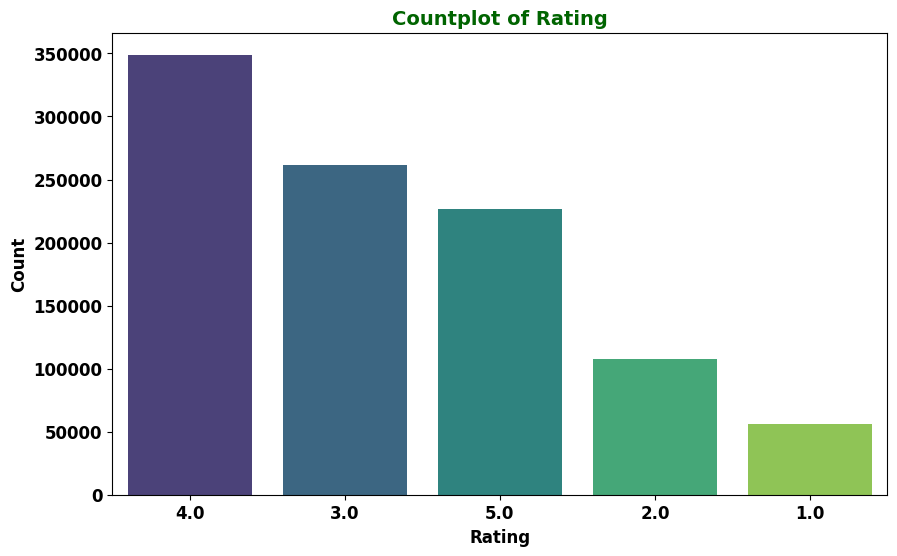

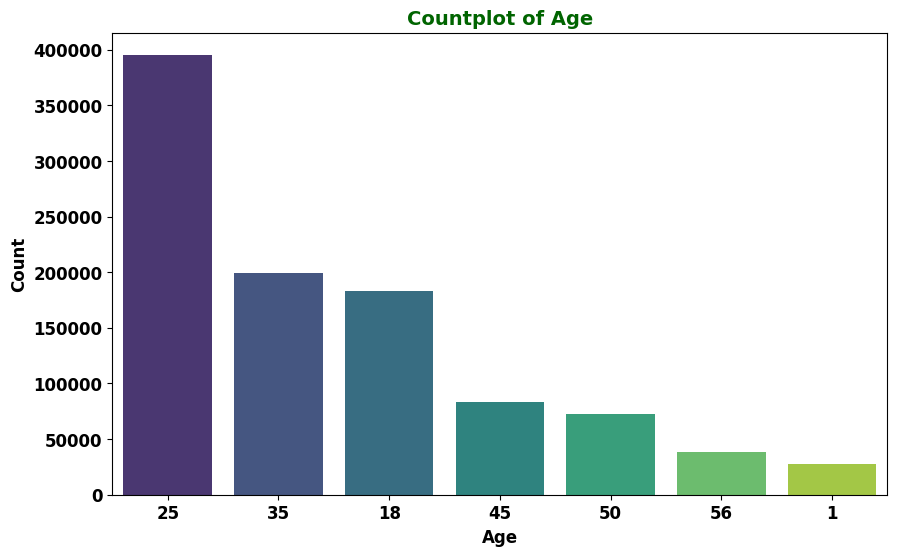

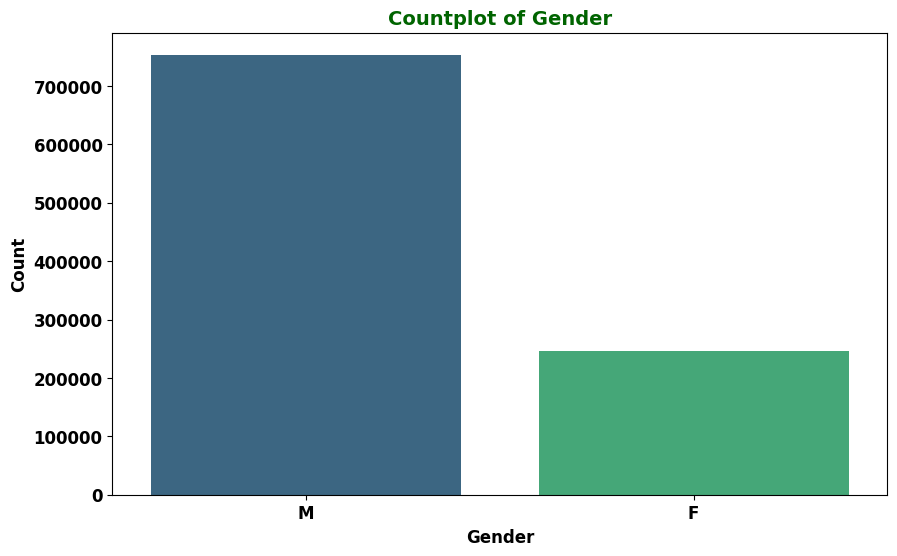

In [ ]:
# Countplot of Rating, Age, Gender
categorical_cols = ['Rating', 'Age', 'Gender']
for col in categorical_cols:
    plt.figure(figsize = (10, 6))
    sns.countplot(data = df, x = col, palette = 'viridis', order = df[col].value_counts().index)
    plt.title(f'Countplot of {col}', fontsize = 14, fontweight = 'bold', color = 'darkgreen')
    plt.xlabel(col, fontsize = 12, fontweight = 'bold')
    plt.ylabel('Count', fontsize = 12, fontweight = 'bold')
    plt.xticks(fontsize = 12, fontweight = 'bold')
    plt.yticks(fontsize = 12, fontweight = 'bold')
    plt.show()

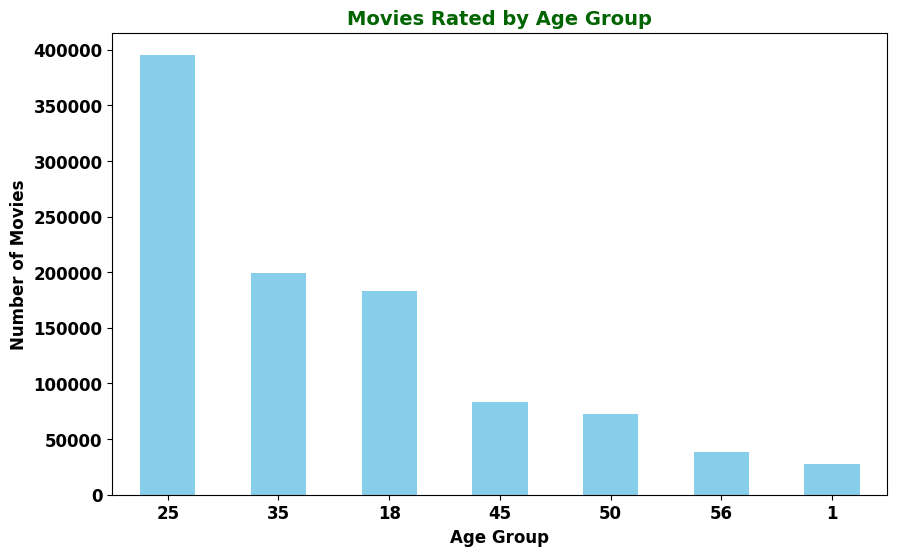

In [ ]:
# Active Age Groups
age_counts = df.groupby('Age')['MovieID'].count().sort_values(ascending = False)
plt.figure(figsize = (10, 6))
age_counts.plot(kind = 'bar', color = 'skyblue')
plt.title("Movies Rated by Age Group", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Age Group", fontsize = 12, fontweight = 'bold')
plt.ylabel("Number of Movies", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold', rotation = 0)
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.show()

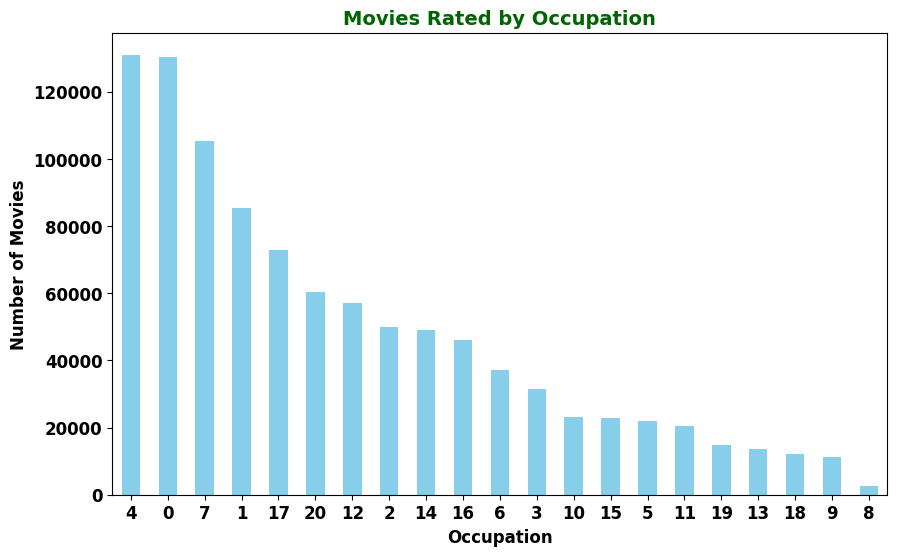

In [ ]:
# Active Occupations
plt.figure(figsize = (10, 6))
occupation_counts = df.groupby('Occupation')['MovieID'].count().sort_values(ascending = False)
occupation_counts.plot(kind = 'bar', color = 'skyblue')
plt.title("Movies Rated by Occupation", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Occupation", fontsize = 12, fontweight = 'bold')
plt.ylabel("Number of Movies", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold', rotation = 0)
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.show()

                                               Title  avg_rating  num_ratings
126                                  American Beauty    4.317386         3428
3117              Star Wars: Episode IV - A New Hope    4.453694         2991
3118  Star Wars: Episode V - The Empire Strikes Back    4.292977         2990
3119      Star Wars: Episode VI - Return of the Jedi    4.022893         2883
1773                                   Jurassic Park    3.763847         2672
2860                             Saving Private Ryan    4.337354         2653
3257                      Terminator 2: Judgment Day    4.058513         2649
2089                                     Matrix, The    4.315830         2590
257                               Back to the Future    3.990321         2583
2954                       Silence of the Lambs, The    4.351823         2578
2118                                    Men in Black    3.739953         2538
2678                         Raiders of the Lost Ark    4.477725

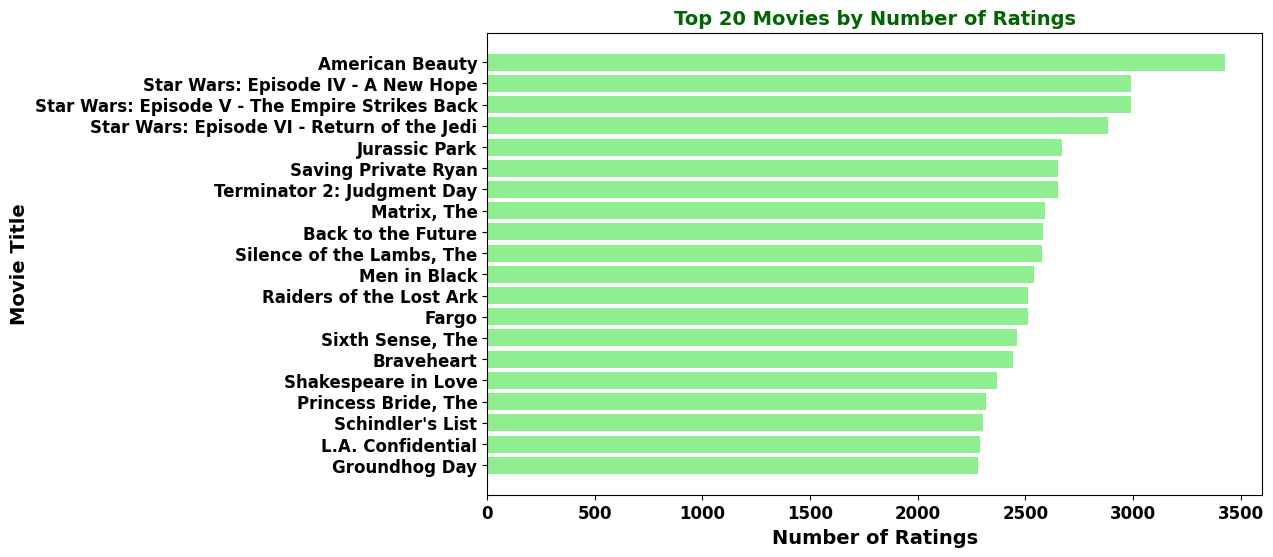

In [ ]:
# Top 20 Movies by number of ratings
# Top 20 movies
top_20_movies = movie_stats.sort_values(by = 'num_ratings', ascending = False).head(20)
print(top_20_movies)

# Plot
plt.figure(figsize = (10,6))
plt.barh(top_20_movies['Title'], top_20_movies['num_ratings'], color = 'lightgreen')
plt.title("Top 20 Movies by Number of Ratings", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Number of Ratings", fontsize = 14, fontweight = 'bold')
plt.ylabel("Movie Title", fontsize = 14, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold')
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.gca().invert_yaxis()
plt.show()

Genres
Comedy         356580
Drama          354529
Action         257457
Thriller       189680
Sci-Fi         157294
Romance        147523
Adventure      133953
Crime           79541
Horror          76386
Children's      72186
War             68527
Animation       43293
Musical         41533
Mystery         40178
Fantasy         36301
Western         20683
Film-Noir       18261
Documentary      7910
Name: count, dtype: int64


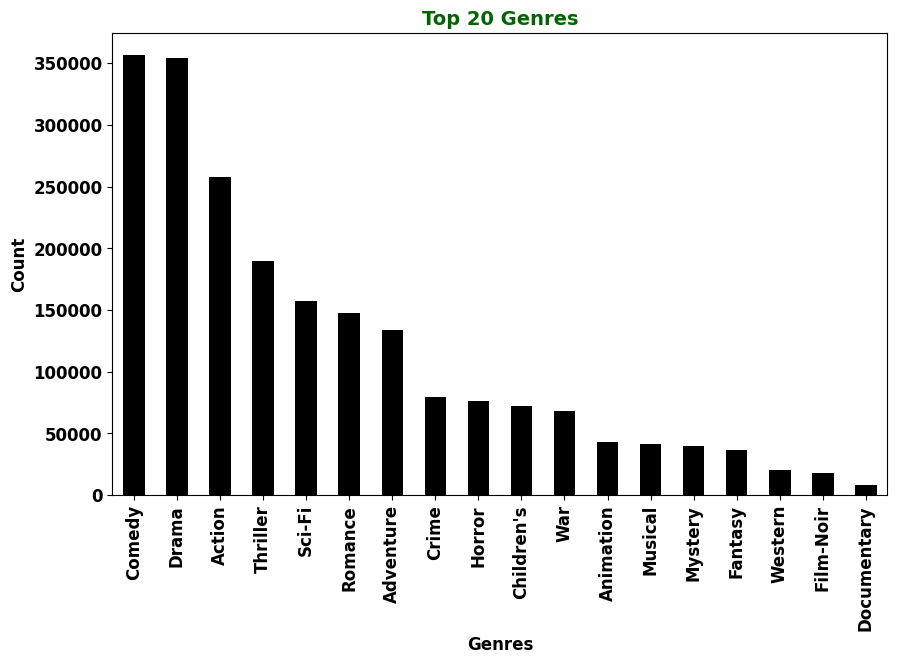

In [ ]:
# Top 20 Genres
# Genre Counts
genre_counts = (df['Genres'].str.split('|').explode().value_counts().head(20))
print(genre_counts)

# Plot
plt.figure(figsize = (10, 6))
genre_counts.plot(kind = 'bar', color = 'black')
plt.title("Top 20 Genres", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Genres", fontsize = 12, fontweight = 'bold')
plt.ylabel("Count", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold')
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.show()

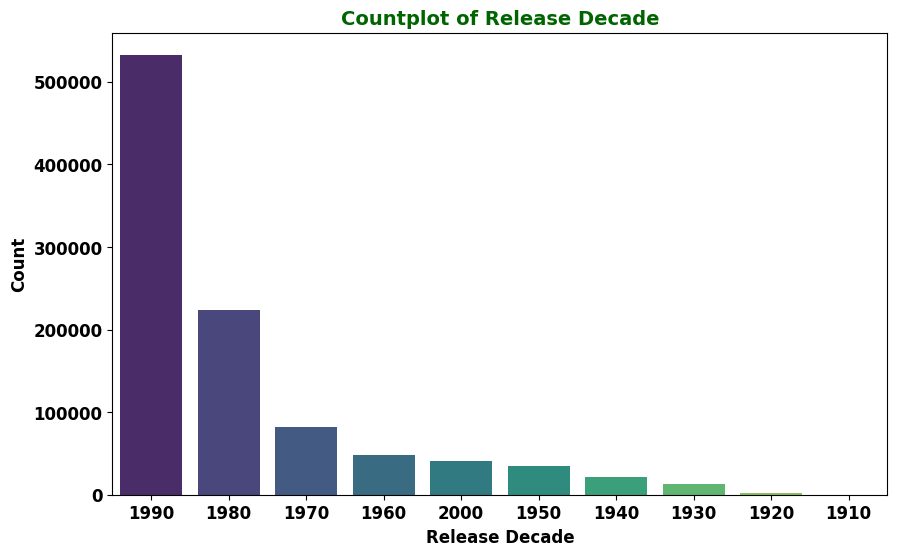

In [ ]:
# Countplot of Release Decade
plt.figure(figsize = (10, 6))
sns.countplot(x = 'Release_Decade', data = df, palette = 'viridis', order = df['Release_Decade'].value_counts().index)
plt.title("Countplot of Release Decade", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Release Decade", fontsize = 12, fontweight = 'bold')
plt.ylabel("Count", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold')
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.show()

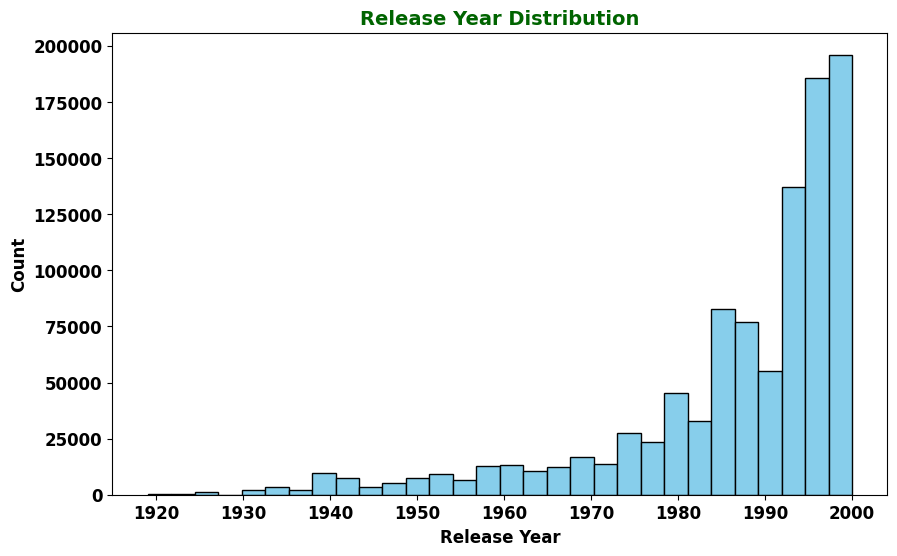

In [ ]:
# Release Year Distribution
plt.figure(figsize = (10, 6))
df['Release_Year'].dropna().hist(bins = 30, color = 'skyblue', edgecolor = 'black')
plt.title("Release Year Distribution", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Release Year", fontsize = 12, fontweight = 'bold')
plt.ylabel("Count", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold')
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.grid(False)
plt.show()

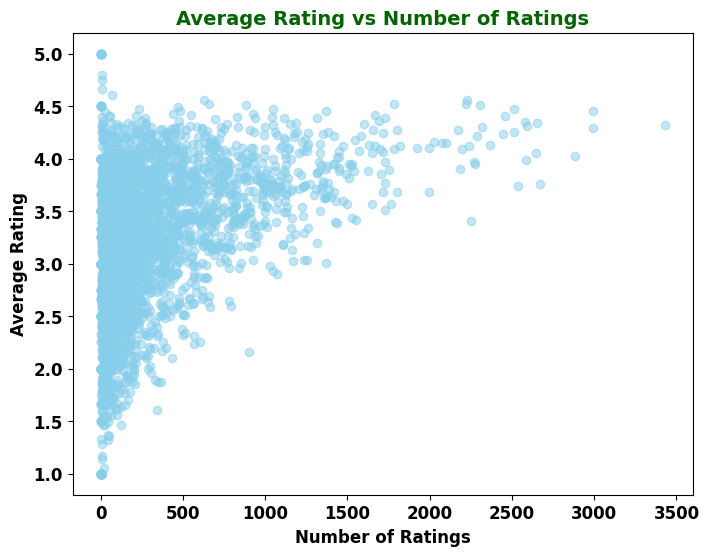

In [ ]:
# Avg Rating vs Num Ratings
plt.figure(figsize = (8, 6))
plt.scatter(movie_stats['num_ratings'], movie_stats['avg_rating'], alpha = 0.5, color = 'skyblue')
plt.title("Average Rating vs Number of Ratings", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Number of Ratings", fontsize = 12, fontweight = 'bold')
plt.ylabel("Average Rating", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold')
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.grid(False)
plt.show()

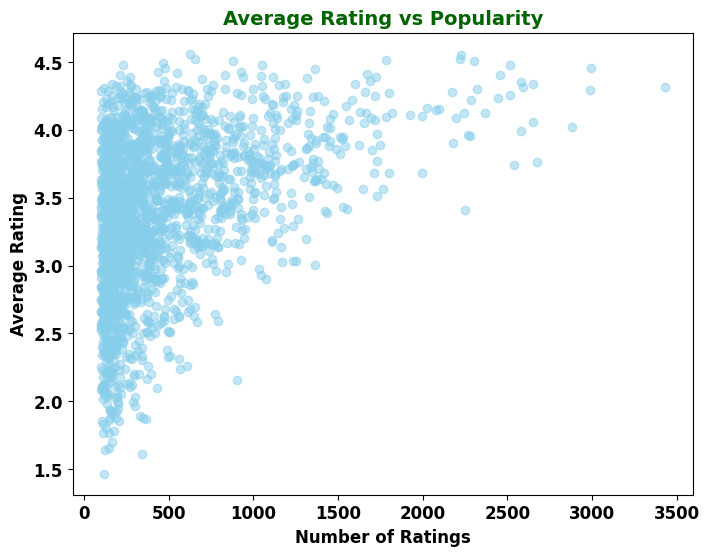

In [ ]:
# Avg Rating vs Popularity
filtered = movie_stats[movie_stats['num_ratings'] > 100]
plt.figure(figsize = (8, 6))
plt.scatter(filtered['num_ratings'], filtered['avg_rating'], alpha = 0.5, color = 'skyblue')
plt.title("Average Rating vs Popularity", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Number of Ratings", fontsize = 12, fontweight = 'bold')
plt.ylabel("Average Rating", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold')
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.show()

## **Movies with very few ratings tend to have unreliable average ratings. Therefore, a threshold (e.g., >100 ratings) was applied to filter out noisy data and better analyze the relationship between popularity and rating.**

# **Part 3: Pivot Table (User–Item Matrix)**

In [ ]:
# Create User-Item matrix
pivot_table = df.pivot_table(index = 'Title', columns = 'UserID', values = 'Rating')

# View shape
print("Pivot table shape:", pivot_table.shape)

# Preview
pivot_table.head()

Pivot table shape: (3664, 6040)


UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
'Night Mother,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
'Til There Was You,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"'burbs, The",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...And Justice for All,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Handle Missing Values
pivot_table.fillna(0, inplace = True)
pivot_table.head()

UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
'Night Mother,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0
'Til There Was You,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"'burbs, The",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...And Justice for All,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Check Sparsity
total_cells = pivot_table.size
non_zero = (pivot_table > 0).sum().sum()
print("Sparsity (%):", 100 - (non_zero / total_cells) * 100)

Sparsity (%): 95.4945333511669


In [ ]:
# Sanity Check
print(pivot_table.isnull().sum().sum())

0


# **Part 4: Recommender Systems**

# **Part 4A: Build a Recommender System based on Pearson Correlation**

In [ ]:
# Compute Correlation Matrix
# Compute Pearson correlation between movies
corr_matrix = pivot_table.T.corr(method = 'pearson')

# Check the Matrix
print(corr_matrix.shape)
corr_matrix.head()

(3664, 3664)


Title,"$1,000,000 Duck",'Night Mother,'Til There Was You,"'burbs, The",...And Justice for All,1-900,10 Things I Hate About You,101 Dalmatians,12 Angry Men,"13th Warrior, The",...,"Young Poisoner's Handbook, The",Young Sherlock Holmes,Young and Innocent,Your Friends and Neighbors,Zachariah,"Zed & Two Noughts, A",Zero Effect,Zero Kelvin (Kjærlighetens kjøtere),Zeus and Roxanne,eXistenZ
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck",1.000000,0.065338,0.030805,0.065478,0.048708,-0.001319,0.036612,0.175724,0.075665,0.036112,...,0.030758,0.060574,-0.002833,0.035056,-0.001237,0.040590,0.024165,-0.001332,0.116574,0.009243
'Night Mother,0.065338,1.000000,0.107374,0.096778,0.144480,-0.001834,0.046122,0.109631,0.083988,0.013045,...,0.042061,0.065333,0.060202,0.124593,-0.001719,0.085001,0.054343,-0.001852,-0.005825,0.054699
'Til There Was You,0.030805,0.107374,1.000000,0.082706,0.051965,0.079011,0.105672,0.105814,0.054821,0.040220,...,0.019685,0.043294,-0.003341,0.068935,-0.001459,0.016935,0.062262,-0.001571,0.042842,0.043483
"'burbs, The",0.065478,0.096778,0.082706,1.000000,0.110790,-0.003821,0.133881,0.195062,0.113112,0.139186,...,0.092597,0.165666,0.012226,0.114837,-0.003582,0.042862,0.121617,-0.003858,0.022249,0.062471
...And Justice for All,0.048708,0.144480,0.051965,0.110790,1.000000,-0.003203,0.018614,0.128837,0.160556,0.068781,...,0.071819,0.115402,0.061253,0.088616,-0.003002,0.075720,0.075804,0.072283,-0.010171,0.071000


In [ ]:
# Create Recommendation Function
def recommend_movies(movie_name, n = 5):
    # Check if movie exists
    if movie_name not in corr_matrix:
        return "Movie not found in dataset"

    # Get similarity scores
    similar_movies = corr_matrix[movie_name].sort_values(ascending = False)

    # Remove the movie itself (first entry)
    similar_movies = similar_movies.drop(movie_name)

    # Return top N recommendations
    return similar_movies.head(n)

In [ ]:
# Test the Recommender
recommend_movies("Toy Story (1995)")

'Movie not found in dataset'

In [ ]:
# Test the Recommender
recommend_movies("Young and Innocent")

,Young and Innocent
Title,
Blackmail,0.529457
Secret Agent,0.434836
Murder!,0.424876
Cavalcade,0.420544
Sabotage,0.376568


In [ ]:
# Test the Recommender
recommend_movies("10 Things I Hate About You", 5)

,10 Things I Hate About You
Title,
She's All That,0.409002
Never Been Kissed,0.400310
American Pie,0.368416
Cruel Intentions,0.348174
Big Daddy,0.337655


In [ ]:
# Filter movies with low ratings (to avoid noise):
def recommend_movies_filtered(movie_name, n = 5, min_ratings = 100):

    # Filter valid movies
    valid_movies = movie_stats[movie_stats['num_ratings'] >= min_ratings]['Title']

    similar_movies = corr_matrix[movie_name].drop(movie_name)

    # Keep only popular movies
    similar_movies = similar_movies[similar_movies.index.isin(valid_movies)]

    return similar_movies.sort_values(ascending = False).head(n)

In [ ]:
# Test the Recommender
recommend_movies_filtered("Young and Innocent")

,Young and Innocent
Title,
"Lady Vanishes, The",0.192365
Rope,0.188057
Spellbound,0.187742
Ninotchka,0.183466
"39 Steps, The",0.181319


In [ ]:
# Test the Recommender
recommend_movies_filtered("10 Things I Hate About You")

,10 Things I Hate About You
Title,
She's All That,0.409002
Never Been Kissed,0.400310
American Pie,0.368416
Cruel Intentions,0.348174
Big Daddy,0.337655


In [ ]:
# Test the Recommender
recommend_movies_filtered("Young Sherlock Holmes")

,Young Sherlock Holmes
Title,
Indiana Jones and the Temple of Doom,0.370317
Willow,0.353126
Batman,0.351804
Superman II,0.346614
Romancing the Stone,0.343151


# **Part 4B: Build a Recommender System based on Cosine Similarity**

In [ ]:
# Import all the required libraries
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

In [ ]:
# Item–Item Similarity Matrix
# Compute item similarity
item_similarity = cosine_similarity(pivot_table)

# Convert to DataFrame
item_sim_df = pd.DataFrame(item_similarity, index = pivot_table.index, columns = pivot_table.index)
print("Item similarity matrix shape:", item_sim_df.shape)
item_sim_df.head()

Item similarity matrix shape: (3664, 3664)


Title,"$1,000,000 Duck",'Night Mother,'Til There Was You,"'burbs, The",...And Justice for All,1-900,10 Things I Hate About You,101 Dalmatians,12 Angry Men,"13th Warrior, The",...,"Young Poisoner's Handbook, The",Young Sherlock Holmes,Young and Innocent,Your Friends and Neighbors,Zachariah,"Zed & Two Noughts, A",Zero Effect,Zero Kelvin (Kjærlighetens kjøtere),Zeus and Roxanne,eXistenZ
Title,,,,,,,,,,,,,,,,,,,,,
"$1,000,000 Duck",1.000000,0.072357,0.037011,0.079291,0.060838,0.00000,0.058619,0.189843,0.094785,0.058418,...,0.038725,0.076474,0.000000,0.044074,0.0,0.045280,0.039395,0.000000,0.120242,0.027003
'Night Mother,0.072357,1.000000,0.115290,0.115545,0.159526,0.00000,0.076798,0.137135,0.111413,0.046135,...,0.053010,0.087828,0.063758,0.135962,0.0,0.091150,0.074787,0.000000,0.000000,0.077807
'Til There Was You,0.037011,0.115290,1.000000,0.098756,0.066301,0.08025,0.127895,0.128523,0.079115,0.066598,...,0.029200,0.062893,0.000000,0.079187,0.0,0.022594,0.079261,0.000000,0.047526,0.063284
"'burbs, The",0.079291,0.115545,0.098756,1.000000,0.143620,0.00000,0.192191,0.250140,0.170719,0.197808,...,0.113386,0.207897,0.019962,0.138064,0.0,0.055704,0.161174,0.000000,0.033567,0.110525
...And Justice for All,0.060838,0.159526,0.066301,0.143620,1.000000,0.00000,0.075093,0.178928,0.205486,0.122431,...,0.089998,0.153006,0.067009,0.109029,0.0,0.086080,0.110867,0.074317,0.000000,0.111040


In [ ]:
# User–User Similarity Matrix
# Compute user similarity
user_similarity = cosine_similarity(pivot_table.T)

# Convert to DataFrame
user_sim_df = pd.DataFrame(user_similarity, index = pivot_table.columns, columns = pivot_table.columns)
print("User similarity matrix shape:", user_sim_df.shape)
user_sim_df.head()

User similarity matrix shape: (6040, 6040)


UserID,1,2,3,4,5,6,7,8,9,10,...,6031,6032,6033,6034,6035,6036,6037,6038,6039,6040
UserID,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.096382,0.120610,0.132455,0.090158,0.179222,0.059678,0.138241,0.226148,0.254736,...,0.170588,0.082006,0.090961,0.033663,0.114877,0.186957,0.136233,0.000000,0.174604,0.133590
2,0.096382,1.000000,0.151479,0.171176,0.114394,0.100865,0.305787,0.211120,0.190198,0.227745,...,0.112503,0.091222,0.268565,0.014286,0.183384,0.229011,0.206660,0.066118,0.066457,0.218276
3,0.120610,0.151479,1.000000,0.151227,0.062907,0.074603,0.138332,0.077656,0.126457,0.214487,...,0.092960,0.125864,0.161507,0.000000,0.097308,0.143747,0.107945,0.120234,0.094675,0.133144
4,0.132455,0.171176,0.151227,1.000000,0.045094,0.013529,0.130339,0.100856,0.093651,0.121208,...,0.163629,0.093041,0.382803,0.000000,0.082097,0.171158,0.127703,0.062907,0.064634,0.137968
5,0.090158,0.114394,0.062907,0.045094,1.000000,0.047449,0.126257,0.220817,0.261330,0.117508,...,0.100652,0.035732,0.065278,0.054151,0.179083,0.294354,0.173009,0.020459,0.027689,0.241437


In [ ]:
# Item-Based Recommendation Function (Cosine)
def recommend_movies_cosine(movie_name, n = 5):

    if movie_name not in item_sim_df:
        return "Movie not found"
    similar_movies = item_sim_df[movie_name].sort_values(ascending = False)

    # Remove itself
    similar_movies = similar_movies.drop(movie_name)
    return similar_movies.head(n)

In [ ]:
recommend_movies_cosine("Liar Liar (1997)", 5)

'Movie not found'

In [ ]:
recommend_movies_cosine("Zero Effect", 5)

,Zero Effect
Title,
"Big Lebowski, The",0.371472
Jackie Brown,0.342371
Bound,0.337928
"Hudsucker Proxy, The",0.332572
Ed Wood,0.332048


In [ ]:
recommend_movies_cosine("Zeus and Roxanne", 5)

,Zeus and Roxanne
Title,
I'll Be Home For Christmas,0.267964
Fluke,0.234359
Telling You,0.227429
Meet the Deedles,0.199684
Psycho Beach Party,0.190847


In [ ]:
# Create CSR Matrix
csr_data = csr_matrix(pivot_table.values)
print("CSR matrix shape:", csr_data.shape)

CSR matrix shape: (3664, 6040)


In [ ]:
# KNN Model
# Build KNN model
knn_model = NearestNeighbors(metric = 'cosine', algorithm = 'brute')
knn_model.fit(pivot_table)

NearestNeighbors(algorithm='brute', metric='cosine')

In [ ]:
# KNN Recommendation Function
def knn_recommend(movie_name, n = 5):
    if movie_name not in pivot_table.index:
        return "Movie not found"

    movie_index = pivot_table.index.get_loc(movie_name)
    distances, indices = knn_model.kneighbors(pivot_table.iloc[movie_index, :].values.reshape(1, -1), n_neighbors = n+1)   # +1 because first result is itself

    recommendations = []
    for i in range(1, len(distances.flatten())):
      recommendations.append((pivot_table.index[indices.flatten()[i]], distances.flatten()[i]))
    return recommendations

In [ ]:
# Test KNN
knn_recommend("Liar Liar (1997)", 5)

'Movie not found'

In [ ]:
# Test KNN
knn_recommend("101 Dalmatians", 5)

[('Bambi', np.float64(0.48204202415038866)),
 ('Cinderella', np.float64(0.48629129012585015)),
 ('Dumbo', np.float64(0.48880432533494667)),
 ('Pinocchio', np.float64(0.4902754100497744)),
 ('Peter Pan', np.float64(0.49650036172294054))]

In [ ]:
# Test KNN
knn_recommend("12 Angry Men", 5)

[('Amadeus', np.float64(0.5948586505726441)),
 ('To Kill a Mockingbird', np.float64(0.6014269779739088)),
 ('Citizen Kane', np.float64(0.6139128059855191)),
 ('Rear Window', np.float64(0.6202197984662066)),
 ('Bridge on the River Kwai, The', np.float64(0.6214667286106264))]

## **Cosine similarity was used to compute both item-item and user-user similarity matrices. A K-Nearest Neighbors model was trained using cosine distance to recommend similar movies.**

# **Part 4C: Matrix Factorization**

In [ ]:
# Install Library (Run Once)
!pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 24.8 MB/s eta 0:00:00


In [ ]:
# Import Libraries
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

In [ ]:
# Data Preparation
# Use only required columns
data = df[['UserID', 'MovieID', 'Rating']]

# Define rating scale
reader = Reader(rating_scale = (1, 5))

# Load into Surprise format
dataset = Dataset.load_from_df(data, reader)

In [ ]:
# Train Test Split
trainset, testset = train_test_split(dataset, test_size = 0.2, random_state = 42)

In [ ]:
# Train SVD Model
# Define model (d = latent factors)
model = SVD(n_factors = 4)

# Train
model.fit(trainset)

In [ ]:
# Make Predictions
predictions = model.test(testset)

In [ ]:
# Evaluate the model
# RMSE
rmse = accuracy.rmse(predictions)

# MAPE
def calculate_mape(predictions):
    actual = np.array([pred.r_ui for pred in predictions if pred.r_ui != 0])
    predicted = np.array([pred.est for pred in predictions if pred.r_ui != 0])
    return np.mean(np.abs((actual - predicted) / actual)) * 100

mape = calculate_mape(predictions)
print("MAPE:", mape)

RMSE: 0.8775
MAPE: 26.742832058109382


In [ ]:
# Make Sample Prediction
# Predict rating for a specific user & movie
# Predicts -> How much will this user like this movie?
user_id = 1
movie_id = 50
pred = model.predict(user_id, movie_id)
print(pred)

user: 1          item: 50         r_ui = None   est = 4.79   {'was_impossible': False}


## **Based on learned patterns, User 1 is very likely to like Movie 50 (rating ≈ 4.8)**

## **Matrix Factorization decomposes the user-item interaction matrix into latent user and item factors, capturing hidden preferences and characteristics. These embeddings allow better prediction of unknown ratings and improved recommendations.**

## **Matrix Factorization was implemented using Singular Value Decomposition (SVD). A latent space of dimension 4 was used to capture hidden user-item relationships. Model performance was evaluated using RMSE and MAPE.**

# **Part 5: Embeddings Based Similarity**

In [ ]:
# Extract Embeddings
# User embeddings
user_embeddings = model.pu

# Item embeddings
item_embeddings = model.qi

print("User Embeddings Shape:", user_embeddings.shape)
print("Item Embeddings Shape:", item_embeddings.shape)

User Embeddings Shape: (6040, 4)
Item Embeddings Shape: (3675, 4)


In [ ]:
# Map Embeddings to IDs
# Map movie inner id → raw movie id
movie_ids = [trainset.to_raw_iid(i) for i in range(len(item_embeddings))]

# Map user inner id → raw user id
user_ids = [trainset.to_raw_uid(i) for i in range(len(user_embeddings))]

In [ ]:
# Item-Item Similarity using Embeddings
# Compute similarity using item embeddings
item_embedd_sim = cosine_similarity(item_embeddings)

# Convert to DataFrame
item_embedd_sim_df = pd.DataFrame(item_embedd_sim, index = movie_ids, columns = movie_ids)

In [ ]:
# Item Based Recommender Using Embedding
# We need mapping: MovieID → Title
movie_id_to_title = df.drop_duplicates('MovieID').set_index('MovieID')['Title']
title_to_movie_id = dict(zip(df['Title'], df['MovieID']))

In [ ]:
# Item Similarity Recommendation Function
def recommend_movies_embedding(movie_name, n = 5):
    if movie_name not in title_to_movie_id:
        return "Movie not found"

    movie_id = title_to_movie_id[movie_name]

    if movie_id not in item_embedd_sim_df.index:
        return "Movie ID not found in embeddings"

    similar = item_embedd_sim_df[movie_id].sort_values(ascending = False)

    # Remove itself
    similar = similar.drop(movie_id)

    # Convert back to titles
    recommendations = [movie_id_to_title[mid] for mid in similar.head(n).index]
    return recommendations

In [ ]:
# Test the Item Similarity Recommendation Function
recommend_movies_embedding("Liar Liar (1997)", 5)

'Movie not found'

In [ ]:
recommend_movies_embedding("Rear Window", 5)

['Bride of Frankenstein',
 'Notorious',
 'Bridge on the River Kwai, The',
 "I'll Never Forget What's 'is Name",
 'Boat, The (Das Boot)']

In [ ]:
recommend_movies_embedding("Citizen Kane", 5)

['Quiz Show',
 'Garden of Finzi-Contini, The (Giardino dei Finzi-Contini, Il)',
 'From Here to Eternity',
 'Once Upon a Time... When We Were Colored',
 'Invasion of the Body Snatchers']

In [ ]:
# User-User Similarity using Embeddings
# Compute user similarity
user_embedd_sim = cosine_similarity(user_embeddings)

# Convert to DataFrame
user_embedd_sim_df = pd.DataFrame(user_embedd_sim, index = user_ids, columns = user_ids)

In [ ]:
# User Similarity Recommendation Function
def similar_users(user_id, n = 5):
    if user_id not in user_embedd_sim_df:
        return "User not found"

    similar = user_embedd_sim_df[user_id].sort_values(ascending = False)
    similar = similar.drop(user_id)
    result = similar.head(n).reset_index()
    result.columns = ['Similar UserID', 'Similarity Score']
    return result

In [ ]:
# Test the User Similarity Recommendation Function
similar_users(1, 5)

,Similar UserID,Similarity Score
0,1246,0.999827
1,4394,0.995361
2,3616,0.993703
3,1878,0.985718
4,4474,0.985420


# **Train MF with d = 2**

In [ ]:
# Train MF with d = 2
model_2d = SVD(n_factors = 2)
model_2d.fit(trainset)
item_emb_2d = model_2d.qi

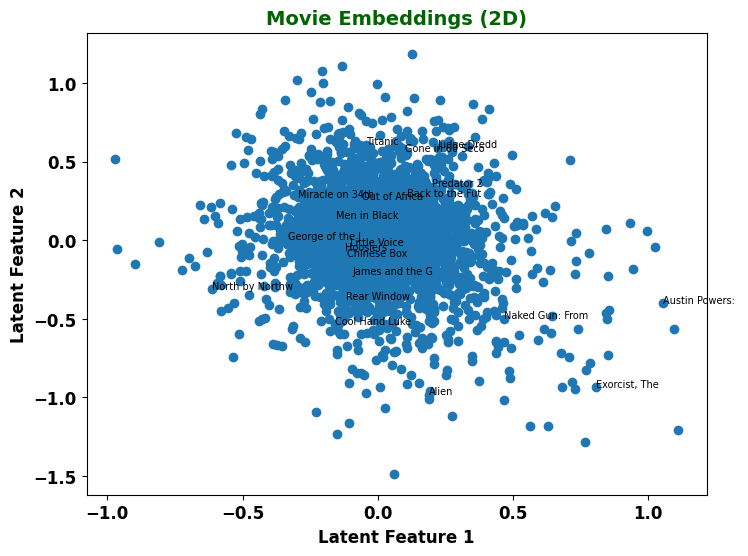

In [ ]:
# Plot Movie Embeddings
x = item_emb_2d[:, 0]
y = item_emb_2d[:, 1]

plt.figure(figsize = (8,6))
plt.scatter(x, y)

for i in range(20):
    movie_id = int(movie_ids[i])
    title = movie_id_to_title[movie_id]
    plt.text(x[i], y[i], title[:15], fontsize = 7)  # truncate long titles

plt.title("Movie Embeddings (2D)", fontsize = 14, fontweight = 'bold', color = 'darkgreen')
plt.xlabel("Latent Feature 1", fontsize = 12, fontweight = 'bold')
plt.ylabel("Latent Feature 2", fontsize = 12, fontweight = 'bold')
plt.xticks(fontsize = 12, fontweight = 'bold')
plt.yticks(fontsize = 12, fontweight = 'bold')
plt.grid(False)
plt.show()

# **📊 Observations:**

**Movies cluster together → similar preference groups**

**Nearby points → movies with similar latent characteristics**

**Distant points → very different genres/preferences**

**Latent features capture hidden attributes (not explicit genres)**

## **Embedding-based similarity captures hidden relationships between items and users, leading to more robust and meaningful recommendations compared to similarity computed on sparse rating data.**

## **User-user similarity was also computed using latent embeddings. Similar users were identified based on cosine similarity of their learned latent factors.**

# **Part 4D: Build a Recommender System based Pearson Correlation**

In [ ]:
# Select Movies for Simulating New User Input
pivot_table.index[:20]

Index(['$1,000,000 Duck', ''Night Mother', ''Til There Was You', ''burbs, The',
       '...And Justice for All', '1-900', '10 Things I Hate About You',
       '101 Dalmatians', '12 Angry Men', '13th Warrior, The', '187',
       '2 Days in the Valley', '20 Dates', '20,000 Leagues Under the Sea',
       '200 Cigarettes', '2001: A Space Odyssey', '2010',
       '24 7: Twenty Four Seven', '24-hour Woman', '28 Days'],
      dtype='object', name='Title')

In [ ]:
# Simulate New User Input
new_user_ratings = {"13th Warrior": 5, "12 Angry Men)": 4, "101 Dalmatians": 3, "20 Dates": 2}

# Convert to DataFrame
new_user_df = pd.DataFrame(list(new_user_ratings.items()), columns = ['Title', 'Rating'])
new_user_df

,Title,Rating
0,13th Warrior,5
1,12 Angry Men),4
2,101 Dalmatians,3
3,20 Dates,2


In [ ]:
# Merge with Existing Ratings
# Merge with original dataset to get UserID mapping
merged = pd.merge(new_user_df, df, on = 'Title')

# Keep only relevant columns
merged = merged[['UserID', 'Title', 'Rating_x']]
merged.columns = ['UserID', 'Title', 'Rating']

In [ ]:
# Find Overlapping Users
# Count common movies per user
common_users = merged.groupby('UserID').count()['Title'].sort_values(ascending = False)

In [ ]:
# Select Top 100 Users
top_users = common_users.head(100).index
filtered_users = df[df['UserID'].isin(top_users)]

In [ ]:
# Compute Pearson Similarity
from scipy.stats import pearsonr
similarity_scores = []

for user in top_users:
    user_data = filtered_users[filtered_users['UserID'] == user]
    merged_data = pd.merge(new_user_df, user_data, on = 'Title')

    if len(merged_data) >= 2:
        corr, _ = pearsonr(merged_data['Rating_x'], merged_data['Rating_y'])
        similarity_scores.append((user, corr))

In [ ]:
# Create Similarity DataFrame
similarity_df = pd.DataFrame(similarity_scores, columns = ['UserID', 'Similarity'])

# Sort
similarity_df = similarity_df.sort_values(by = 'Similarity', ascending = False)

# Top 10 similar users
top_similar_users = similarity_df.head(15)
top_similar_users

,UserID,Similarity
7,5754,1.0
77,4084,1.0
0,5948,-0.5
1,4867,-0.5
33,5084,-1.0
2,2106,NaN
3,5811,NaN
4,5925,NaN
5,183,NaN
6,5762,NaN


In [ ]:
# Create similarity DataFrame
similarity_df = pd.DataFrame(similarity_scores, columns = ['UserID', 'Similarity'])

# Remove NaN values
similarity_df = similarity_df.dropna()

# Keep only positive similarity users
similarity_df = similarity_df[similarity_df['Similarity'] > 0]

# Sort
similarity_df = similarity_df.sort_values(by = 'Similarity', ascending = False)

# Take Top 10 users
top_similar_users = similarity_df.head(10)
top_similar_users

,UserID,Similarity
7,5754,1.0
77,4084,1.0


## **While Pearson similarity was computed for all users, only users with positive similarity scores were considered for generating recommendations, as negative correlations indicate opposite preferences.**

In [ ]:
# Get Movies from Similar Users
top_users_ids = top_similar_users['UserID']
similar_users_movies = df[df['UserID'].isin(top_users_ids)]

In [ ]:
# Remove Movies Already Rated by New User
movies_to_recommend = similar_users_movies[~similar_users_movies['Title'].isin(new_user_df['Title'])]

In [ ]:
# Compute Weighted Ratings
# Merge similarity scores
movies_with_sim = pd.merge(movies_to_recommend, top_similar_users, on = 'UserID')

# Weighted rating
movies_with_sim['Weighted_Rating'] = (movies_with_sim['Rating'] * movies_with_sim['Similarity'])

In [ ]:
# Compute Final Scores
recommendation_scores = movies_with_sim.groupby('Title').agg(total_weighted = ('Weighted_Rating', 'sum'),
                                                             total_similarity = ('Similarity', 'sum'))

# Final score
recommendation_scores['Score'] = (recommendation_scores['total_weighted'] / recommendation_scores['total_similarity'])

In [ ]:
# Recommend Top Movies
final_recommendations = recommendation_scores.sort_values(by = 'Score', ascending = False).head(10)
final_recommendations

,total_weighted,total_similarity,Score
Title,,,
"20,000 Leagues Under the Sea",5.0,1.0,5.0
"Killing Fields, The",5.0,1.0,5.0
"Straight Story, The",5.0,1.0,5.0
Interiors,5.0,1.0,5.0
Bonnie and Clyde,5.0,1.0,5.0
Annie Hall,5.0,1.0,5.0
Anatomy of a Murder,5.0,1.0,5.0
Stalag 17,5.0,1.0,5.0
Marty,5.0,1.0,5.0


## **The final recommendations resulted in identical scores due to a limited number of highly similar users contributing to the recommendations. This indicates that the similarity filtering was strict, resulting in fewer users influencing the prediction. Increasing the number of input ratings or relaxing similarity constraints can improve diversity in recommendations.**

In [ ]:
# Simulate New User Input
new_user_ratings = {"13th Warrior": 5, "12 Angry Men": 4, "101 Dalmatians": 3, "20 Dates": 2,
                    "10 Things I Hate About You": 4, "2001: A Space Odyssey": 2}

# Convert to DataFrame
new_user_df = pd.DataFrame(list(new_user_ratings.items()), columns = ['Title', 'Rating'])
new_user_df

,Title,Rating
0,13th Warrior,5
1,12 Angry Men,4
2,101 Dalmatians,3
3,20 Dates,2
4,10 Things I Hate About You,4
5,2001: A Space Odyssey,2


In [ ]:
# Merge with Existing Ratings
# Merge with original dataset to get UserID mapping
merged = pd.merge(new_user_df, df, on = 'Title')

# Keep only relevant columns
merged = merged[['UserID', 'Title', 'Rating_x']]
merged.columns = ['UserID', 'Title', 'Rating']

In [ ]:
# Find Overlapping Users
# Count common movies per user
common_users = merged.groupby('UserID').count()['Title'].sort_values(ascending = False)

In [ ]:
# Select Top 100 Users
top_users = common_users.head(100).index
filtered_users = df[df['UserID'].isin(top_users)]

In [ ]:
# Compute Pearson Similarity
similarity_scores = []
for user in top_users:
    user_data = filtered_users[filtered_users['UserID'] == user]
    merged_data = pd.merge(new_user_df, user_data, on = 'Title')

    if len(merged_data) >= 2:
        corr, _ = pearsonr(merged_data['Rating_x'], merged_data['Rating_y'])
        similarity_scores.append((user, corr))

In [ ]:
# Create Similarity DataFrame
similarity_df = pd.DataFrame(similarity_scores, columns = ['UserID', 'Similarity'])

# Sort
similarity_df = similarity_df.sort_values(by = 'Similarity', ascending = False)

# Top 20 similar users
top_similar_users = similarity_df.head(20)
top_similar_users

,UserID,Similarity
97,5978,1.000000
20,4815,0.962250
32,2156,0.943880
22,5972,0.899229
37,1010,0.870388
82,1599,0.862662
79,314,0.852803
71,2073,0.852803
72,3842,0.816497
38,2063,0.816497


In [ ]:
# Create similarity DataFrame
similarity_df = pd.DataFrame(similarity_scores, columns = ['UserID', 'Similarity'])

# Remove NaN values
similarity_df = similarity_df.dropna()

# Keep only positive similarity users
similarity_df = similarity_df[similarity_df['Similarity'] > 0]

# Sort
similarity_df = similarity_df.sort_values(by = 'Similarity', ascending = False)

# Take Top 10 users
top_similar_users = similarity_df.head(10)
top_similar_users

,UserID,Similarity
97,5978,1.000000
20,4815,0.962250
32,2156,0.943880
22,5972,0.899229
37,1010,0.870388
82,1599,0.862662
79,314,0.852803
71,2073,0.852803
38,2063,0.816497
68,5185,0.816497


In [ ]:
# Get Movies from Similar Users
top_users_ids = top_similar_users['UserID']
similar_users_movies = df[df['UserID'].isin(top_users_ids)]

In [ ]:
# Remove Movies Already Rated by New User
movies_to_recommend = similar_users_movies[~similar_users_movies['Title'].isin(new_user_df['Title'])]

In [ ]:
# Compute Weighted Ratings
# Merge similarity scores
movies_with_sim = pd.merge(movies_to_recommend, top_similar_users, on = 'UserID')

# Weighted rating
movies_with_sim['Weighted_Rating'] = (movies_with_sim['Rating'] * movies_with_sim['Similarity'])

In [ ]:
# Compute Final Scores
recommendation_scores = movies_with_sim.groupby('Title').agg(total_weighted = ('Weighted_Rating', 'sum'),
                                                             total_similarity = ('Similarity', 'sum'))

# Final score
recommendation_scores['Score'] = (recommendation_scores['total_weighted'] / recommendation_scores['total_similarity'])

In [ ]:
# Recommend Top Movies
final_recommendations = recommendation_scores.sort_values(by = 'Score', ascending = False).head(10)
final_recommendations

,total_weighted,total_similarity,Score
Title,,,
Midnight Cowboy,9.075267,1.815053,5.0
Bringing Up Baby,9.075267,1.815053,5.0
"Ideal Husband, An",8.760158,1.752032,5.0
Mighty Aphrodite,4.496144,0.899229,5.0
"Mighty, The",4.264014,0.852803,5.0
Mr. Smith Goes to Washington,4.264014,0.852803,5.0
"Elephant Man, The",13.427208,2.685442,5.0
Some Mother's Son,4.351941,0.870388,5.0
Metropolis,4.811252,0.962250,5.0


## **Initially, the recommendations resulted in identical scores due to a limited number of highly similar users contributing to the predictions. After increasing the number of input ratings and considering more similar users, the recommendation system incorporated contributions from multiple users.**

## **Although the final scores remain similar, the variation in weighted ratings and similarity values indicates a more robust and reliable recommendation process. This suggests that the recommended movies are consistently highly rated by multiple similar users, reinforcing their relevance for the target user.**

In [ ]:
# Final Recommendations
final_recommendations = final_recommendations.merge(movie_stats[['Title', 'num_ratings']],
                                                    on = 'Title', how = 'left').sort_values(['Score', 'num_ratings'],
                                                                                            ascending=[False, False]).head(10)
final_recommendations

,Title,total_weighted,total_similarity,Score,num_ratings
0,Midnight Cowboy,9.075267,1.815053,5.0,663
1,Bringing Up Baby,9.075267,1.815053,5.0,413
2,"Ideal Husband, An",8.760158,1.752032,5.0,390
6,"Elephant Man, The",13.427208,2.685442,5.0,457
3,Mighty Aphrodite,4.496144,0.899229,5.0,431
8,Metropolis,4.811252,0.962250,5.0,388
5,Mr. Smith Goes to Washington,4.264014,0.852803,5.0,383
4,"Mighty, The",4.264014,0.852803,5.0,134
9,"Navigator: A Mediaeval Odyssey, The",4.811252,0.962250,5.0,110
7,Some Mother's Son,4.351941,0.870388,5.0,20


# **Part 5: Questionnaire**

In [ ]:
# Q1: Users of which age group have watched and rated the most number of movies?
age_group = df.groupby('Age')['MovieID'].count().sort_values(ascending = False)
print(age_group)
print("\nTop Age Group:", age_group.idxmax())

Age
25    395556
35    199003
18    183536
45     83633
50     72490
56     38780
1      27211
Name: MovieID, dtype: int64

Top Age Group: 25


In [ ]:
# Q2: Users belonging to which profession have watched and rated the most movies?
profession = df.groupby('Occupation')['MovieID'].count().sort_values(ascending = False)
print(profession)
print("\nTop Occupation:", profession.idxmax())

Occupation
4     131032
0     130499
7     105425
1      85351
17     72816
20     60397
12     57214
2      50068
14     49109
16     46021
6      37205
3      31623
10     23290
15     22951
5      21850
11     20563
19     14904
13     13754
18     12086
9      11345
8       2706
Name: MovieID, dtype: int64

Top Occupation: 4


## **Occupation 4 is "college/grad student"**

In [ ]:
# Q3: Most of the users in our dataset who’ve rated the movies are Male. (T/F)
gender_counts = df['Gender'].value_counts()
print(gender_counts)
print("\nIs Male majority?", gender_counts['M'] > gender_counts['F'])

Gender
M    753769
F    246440
Name: count, dtype: int64

Is Male majority? True


In [ ]:
# Number of ratings
rating_counts = df.groupby('Gender')['MovieID'].count()

# Number of users
user_counts = df[['UserID', 'Gender']].drop_duplicates()['Gender'].value_counts()
print("Ratings by gender:\n", rating_counts)
print("\nUsers by gender:\n", user_counts)

Ratings by gender:
 Gender
F    246440
M    753769
Name: MovieID, dtype: int64

Users by gender:
 Gender
M    4331
F    1709
Name: count, dtype: int64


## **Is Male majority? True**

In [ ]:
# Q4: Most of the movies present in our dataset were released in which decade? a. 70s b. 90s c. 50s d.80s
decade_counts = df['Release_Decade'].value_counts().sort_index()
print(decade_counts)
print("\nMost common decade:", decade_counts.idxmax(), "s")

Release_Decade
1910        45
1920      1696
1930     12729
1940     21501
1950     35232
1960     48555
1970     82552
1980    224056
1990    532843
2000     41000
Name: count, dtype: Int64

Most common decade: 1990 s


In [ ]:
# Q5: The movie with maximum no. of ratings is ___.
movie_stats = df.groupby('Title').agg(num_ratings = ('Rating', 'count')).reset_index()
top_movie = movie_stats.sort_values(by = 'num_ratings', ascending = False).head(1)

# Extract values
movie_name = top_movie['Title'].values[0]
rating_count = top_movie['num_ratings'].values[0]

# Print
print(f"The movie with maximum no. of ratings is '{movie_name}' with {rating_count} ratings")

The movie with maximum no. of ratings is 'American Beauty' with 3428 ratings


In [ ]:
# Q6: Name the top 3 movies similar to ‘Liar Liar’ on the item-based approach.
recommend_movies("Liar Liar", n = 3)

,Liar Liar
Title,
Mrs. Doubtfire,0.499927
Dumb & Dumber,0.459601
Ace Ventura: Pet Detective,0.458654


In [ ]:
# In case the release year is in the title
recommend_movies("Liar Liar (1997)", n = 3)

'Movie not found in dataset'

## **Q7: On the basis of approach, Collaborative Filtering methods can be classified into ___-based and ___-based.**

### **On the basis of approach, Collaborative Filtering methods can be classified into User-based and Item-based.**

## **Q8: Pearson Correlation ranges between ___ to ___ whereas, Cosine Similarity belongs to the interval between ___ to ___.**

### **Pearson Correlation ranges between -1 to 1 whereas, Cosine Similarity belongs to the interval between 0 to 1.**

## **Q9: Mention the RMSE and MAPE that you got while evaluating the Matrix Factorization model.**

## **RMSE: 0.8805**
## **MAPE: 26.82868000122735**

## **Q10: Give the sparse ‘row’ matrix representation for the following dense matrix -**

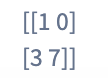

### **Row 0 → (0,1)**
### **Row 1 → (0,3), (1,7)**

# **📊 Insights and Recommendations:**

## **🔍 Key Insights:**

- **Most active users belong to specific age groups (notably 25–34) and professions (e.g., students), indicating concentrated engagement.**

- **The dataset is male-dominated, which may introduce bias in recommendations.**

- **A few movies receive very high ratings, while many have limited ratings, making low-rated-count movies less reliable.**

- **Most movies in the dataset belong to the 1990s decade.**

- **The user–item matrix is highly sparse, affecting similarity-based methods.**

- **Matrix Factorization and embeddings provide better performance by capturing hidden patterns compared to raw rating-based approaches.**

- **User-based recommendations depend on sufficient overlap; fewer similar users lead to less diverse results.**

## **💡 Recommendations:**

- **Use a hybrid approach (item-based + user-based + MF) for better accuracy.**

- **Reduce sparsity by encouraging more user ratings and using latent factor models.**

- **Filter movies with low rating counts to improve recommendation reliability.**

- **Improve diversity by not relying only on highly rated movies.**

- **Use embeddings for scalable and efficient similarity computation.**

- **Continuously update models with new data for better personalization.**

# **📊 Final Conclusions:**

- **The recommender system successfully demonstrates multiple collaborative filtering approaches, each with distinct advantages.**

- **While traditional similarity-based methods provide intuitive recommendations, Matrix Factorization and embedding-based methods offer superior performance in handling sparse data and capturing hidden relationships.**

- **A combination of these techniques, along with careful handling of data quality and user behavior, can lead to a robust, scalable, and highly effective movie recommendation system.**